In [78]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [79]:
def f(x):
    return 3*x**2 - 4*x +5

In [80]:
f(3.0)

20.0

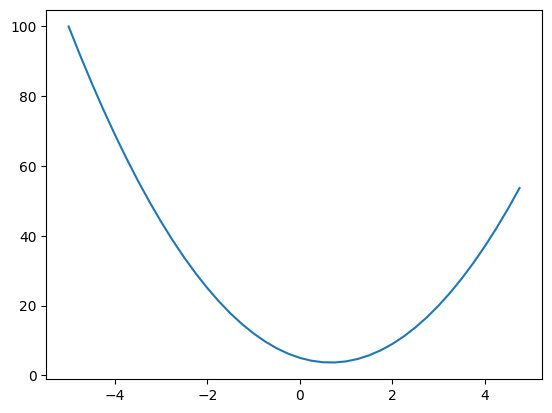

In [81]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [82]:
h = 0.000000001
x = 2/3
(f(x + h) - f(x))/h # 导数定义

0.0

In [83]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a * b + c
print(d)

4.0


In [84]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2-d1)/h)

d1 4.0
d2 4.0001
slope 0.9999999999976694


In [313]:
class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None #默认是一个空函数，什么都不做
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other) 
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad 
        out._backward = _backward
        
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self, ), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        
        return out

    # python 不能执行 a.__mul__(b) 时，会尝试使用 a.__rmul__(b).交换操作
    def __rmul__(self, other): # other * self
        return self * other

    def __truediv__(self, other): # self/other
        return self * other**-1

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __radd__(self, other):
        return self + other

    # tanx = sinx / cosx = (e^x - e^(-x)) / (e^x + e^(-1)) = (e^(2*x) - 1) / (e^(2*x) + 1)
    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')

        def _backward():
            self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self, ), 'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        visited = set()
        # 拓扑排序
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)

        self.grad = 1.0
        for node in reversed(topo):
            node._backward() 

In [86]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label='e'
# a + b # a.__add__(b)
d = e + c; d.label='d' # a.__mul__(b).__add__(c)
f = Value(-2.0, label='f')
L = d * f; L.label='L'
d

Value(data=4.0)

In [87]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [88]:
d._op

'+'

In [89]:
from graphviz import Digraph

def trace(root):
    # build a set of all nodes and edges in a graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph, create a rectangular ('record') node for it
        dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.node(name = uid + n._op, label = n._op)
            # and connect this node to it
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        # connect n1 to the op node of n2
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)
    return dot

In [90]:
L.grad = 1.0
d.grad = -2.0
f.grad = 4.0

L = d * f
dL / dd = ? f
dL / df = d

(f(x+h)-f(x)) / h
((d+h)*f-d*f)/h= hf / h = f

d = c + e
dd / dc = 1.0
dd / de = 1.0

we want: dL/dc (c.grad)

now we know: dL/dd, dd/dc

c.grad = dL/dc = (dL/dd) * (dd/dc)

e = a*b

a.grad = dL/da = (dL/de) * (de/da) = -2.0 * -3.0 = 6

b.grad = -4.0

In [91]:
c.grad = -2.0
e.grad = -2.0
a.grad = 6.0
b.grad = -4.0

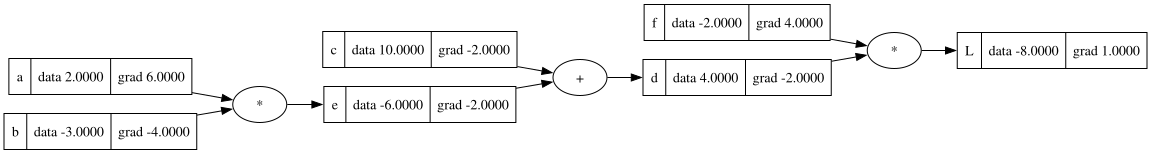

In [92]:
draw_dot(L)

In [93]:
def lol():

    h = 0.001
    
    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    # a + b # a.__add__(b)
    d = e + c; d.label='d' # a.__mul__(b).__add__(c)
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L1 = L.data

    a = Value(2.0, label='a')
    b = Value(-3.0, label='b')
    c = Value(10.0, label='c')
    e = a * b; e.label='e'
    # a + b # a.__add__(b)
    d = e + c; d.label='d' # a.__mul__(b).__add__(c)
    f = Value(-2.0, label='f')
    L = d * f; L.label='L'
    L2 = L.data + h

    print((L2-L1)/h)

lol()

1.000000000000334


In [95]:
a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-6.586368000000001


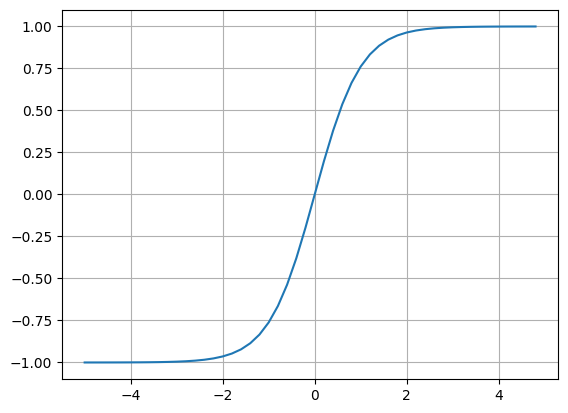

In [97]:
# 激活函数 tanh
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))
plt.grid()

In [187]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1+x2*w2+b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

#激活函数 tanh
o = n.tanh(); o.label='o'

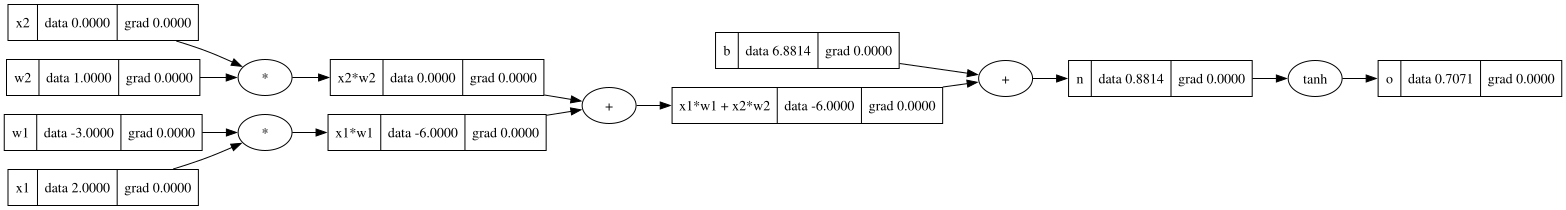

In [188]:
draw_dot(o)

In [126]:
# 手动计算反转传播的导数
# o = n.tanh = tanh(n)
# n.grad = do/dn = 1 - tanh(n)**2 = 1 - o**2

# n = x1*w1 + x2*w2 + b
# x2.grad = w2 * do/dx2w2 = w2 * x2w2.grad = 1.0 * 0.5
x2.grad = 0.5
w2.grad = 0.0
x1.grad = -1.5
w1.grad = 1.0 
x1w1.grad = 0.5
x2w2.grad = 0.5
b.grad = 0.5
x1w1x2w2.grad = 0.5
n.grad = 0.5
o.grad = 1.0

In [108]:
o

Value(data=0.7071067811865476)

In [110]:
1 - o.data**2

0.4999999999999999

In [151]:
o.grad = 1.0

In [152]:
o._backward()

0.4999999999999999


In [154]:
n._backward()

In [156]:
x1w1x2w2._backward()

In [158]:
x1w1._backward()

In [159]:
x2w2._backward()

In [162]:
topo = []
visited = set()
# 拓扑排序
def build_topo(v):
    if v not in visited:
        visited.add(v)
    for child in v._prev:
        build_topo(child)
    topo.append(v)
build_topo(o)

topo

[Value(data=2.0),
 Value(data=-3.0),
 Value(data=-6.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=6.881373587019543),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [167]:
o.grad = 1

topo = []
visited = set()
# 拓扑排序
def build_topo(v):
    if v not in visited:
        visited.add(v)
    for child in v._prev:
        build_topo(child)
    topo.append(v)
build_topo(o)

for node in reversed(topo):
    node._backward() 

In [181]:
o.backward()

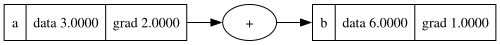

In [189]:
# bug1
a = Value(3.0, label='a')
b = a + a; b.label='b'
b.backward()
draw_dot(b)

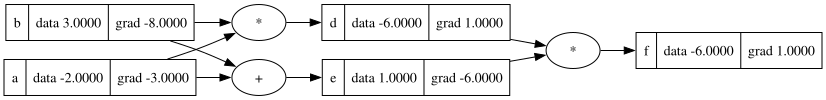

In [190]:
# bug2
a = Value(-2.0, label='a')
b = Value(3.0, label='b')
d = a * b; d.label='d'
e = a + b; e.label='e'
f = d * e; f.label='f'

f.backward()
draw_dot(f)

In [271]:
a = Value(2.0)
b = Value(4.0)
(2 * a).exp()

Value(data=54.598150033144236)

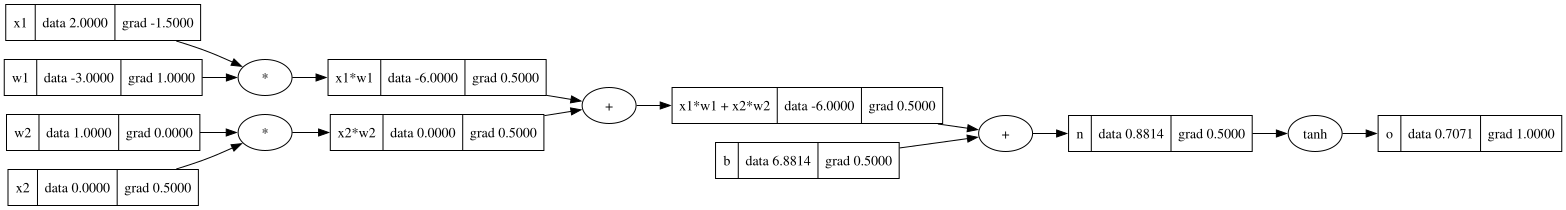

In [282]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1+x2*w2+b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

#激活函数 tanh
o = n.tanh(); o.label='o'
o.backward()
draw_dot(o)

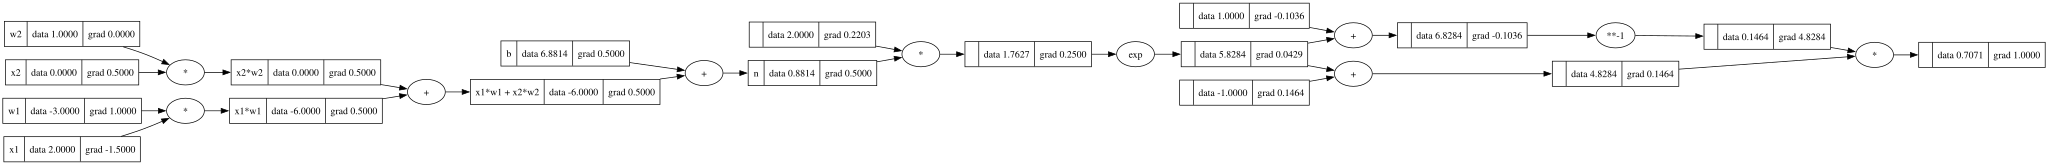

In [315]:
# input x1, x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1, w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1+x2*w2+b
x1w1 = x1*w1; x1w1.label='x1*w1'
x2w2 = x2*w2; x2w2.label='x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label='x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label='n'

#激活函数 tanh
# o = n.tanh(); o.label='o'
e = (2*n).exp()
o = (e - 1) / (e + 1)
o.backward()
draw_dot(o)

In [316]:
import torch

In [318]:
x1 = torch.Tensor([2.0]).double(); x1.requires_grad = True
x2 = torch.Tensor([0.0]).double(); x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double(); w1.requires_grad = True
w2 = torch.Tensor([1.0]).double(); w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double(); b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('-----')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
-----
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


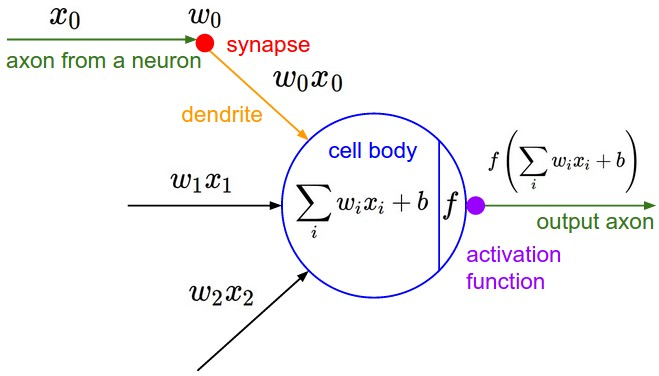

In [518]:
import random

# 单个神经元
class Neuron:
    # 构造函数： nin -> 神经元的输入数量
    def __init__(self, nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1, 1))

    def __call__(self, x):
        # w * x + b
        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b) 
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

x = [2.0, 3.0]
n = Neuron(2) # 初始化一个二维的神经元
n(x) # 将 x 输入到神经元中，得到输出。n(x) --> __call__(x)

Value(data=0.4659850938706152)

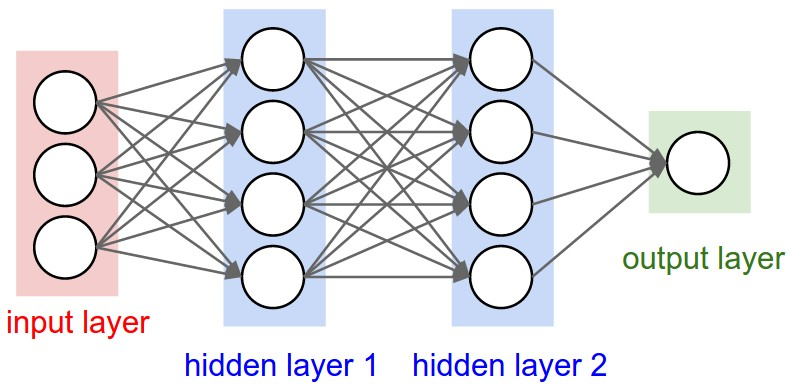

In [519]:
# 神经元层：每一层包含多个神经元，它们彼此之间不连接，但都与输入完全连接。神经元层只是一组独立评估的神经元
class Layer:
    # Layer is just a list of Neurons
    # nin: 输入神经元数量
    # nout: layer 有多少个神经元。
    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
        # params = []
        # for neuron in self.neurons:
        #     ps = neuron.parameters()
        #     params.extends(ps)
        # return params

x = [1.0, 2.0, 3.0]
n = Layer(3, 4)
n(x)

[Value(data=-0.998682794377732),
 Value(data=0.9087020960487852),
 Value(data=0.7148325074714984),
 Value(data=0.9998016863138013)]

In [520]:
# 多层感知机
class MLP:
    # nin: 输入神经元数量
    # nouts: 现在不是单层中的神经元数量，而是一个 nout 的列表，列表定义了 MLP 中所有层的神经元 size 
    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]

    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        return [p for layer in self.layers for neuron in layer.neurons for p in neuron.parameters()]

# 3个输入神经元，两层各 4 个神经元，以及一个输出单元
x = [2.0, 3.0, -1.0]
n = MLP(3, [4, 4, 1])
n(x) # when use this notation n(x), python will use __call__ 

Value(data=0.48720705552288224)

In [371]:
n.parameters()

[Value(data=-0.7978578120570534),
 Value(data=0.07638738670868794),
 Value(data=-0.8280976032595679),
 Value(data=0.48115908749847836),
 Value(data=-0.8168793160186341),
 Value(data=-0.09712029102221509),
 Value(data=-0.4376677227643393),
 Value(data=0.7491972577975983),
 Value(data=0.1142833212905825),
 Value(data=0.9221773932918316),
 Value(data=-0.10416541274743718),
 Value(data=-0.07638271643533812),
 Value(data=-0.4701479678564757),
 Value(data=-0.8536371949879729),
 Value(data=0.7943790548361962),
 Value(data=-0.5003437503157249),
 Value(data=-0.9088089343658674),
 Value(data=0.3471659311053412),
 Value(data=-0.5880067914883231),
 Value(data=0.7072414877127668),
 Value(data=0.9411474933525688),
 Value(data=-0.7226429423232956),
 Value(data=0.7135192551345448),
 Value(data=-0.9229438979524174),
 Value(data=-0.023207752223846967),
 Value(data=0.4085293886609995),
 Value(data=0.9475244134670313),
 Value(data=-0.5528208997207624),
 Value(data=0.2163153836447218),
 Value(data=-0.83516

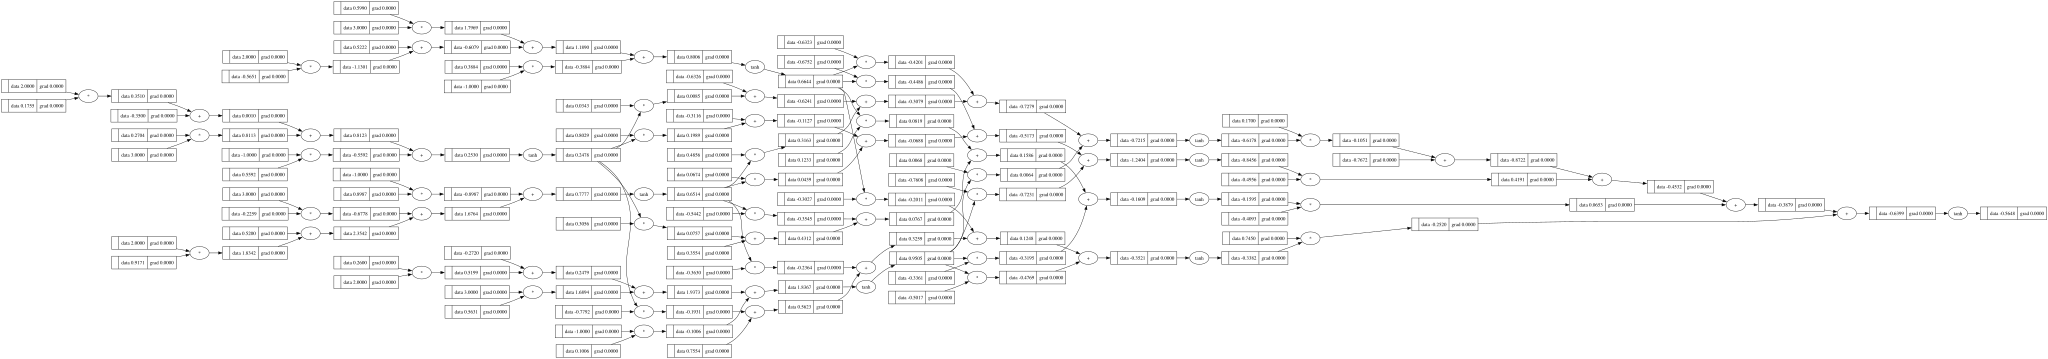

In [337]:
draw_dot(n(x))

In [521]:
# a very simple example dataset
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.0, -1.0],
]

# desired targets
ys = [1.0, -1.0, -1.0, 1.0]

In [530]:
# most common neural net mistakes:
# 1.you didn't try to overfit a single batch first
# 2.you forget to toggle train/eval model for the net
# 3.you forget to .zero_grad() (in pytorch) before .backward()
# 4.you passed softmaxed outputs to a loss that expects raw logits.

for k in range(100):

    # forward pass
    # n是前面定义的 MLP，3个输入神经元，2 个 hidden layer 以及一个 output layer
    ypred = [n(x) for x in xs]
    # 预测值与目标值差距很大，如何调节权重 w, b 来接近目标值？ ---> 损失函数(均方误差)
    loss =  sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0

    # backward pass
    # minimize the loss, if loss if low, then every one of the predictions is equal to it's target
    loss.backward()

    # update
    for p in n.parameters():
        p.data += -0.1 * p.grad

    print(k, loss.data)


# n 是一个 mlp, mlp有多个 layer, 每个 layer 有多个 neurons，每个neurons有 wi, b
# n.layers[0].neurons[0].w[0].grad 

0 0.0005223074880687951
1 0.0005213464477995376
2 0.0005203888605116024
3 0.0005194347077912274
4 0.0005184839713546923
5 0.0005175366330471493
6 0.0005165926748415482
7 0.0005156520788375052
8 0.0005147148272601296
9 0.0005137809024590463
10 0.0005128502869072005
11 0.0005119229631998443
12 0.0005109989140534815
13 0.0005100781223047837
14 0.0005091605709095595
15 0.0005082462429417407
16 0.0005073351215923786
17 0.000506427190168578
18 0.0005055224320925556
19 0.0005046208309006378
20 0.0005037223702422609
21 0.000502827033879046
22 0.0005019348056838044
23 0.0005010456696396119
24 0.0005001596098388539
25 0.000499276610482328
26 0.0004983966558782993
27 0.0004975197304415693
28 0.0004966458186926442
29 0.0004957749052567817
30 0.0004949069748631342
31 0.0004940420123438702
32 0.0004931800026333137
33 0.0004923209307670907
34 0.0004914647818812632
35 0.0004906115412115275
36 0.000489761194092347
37 0.0004889137259561417
38 0.000488069122332483
39 0.0004872273688472788
40 0.0004863884

In [531]:
ypred

[Value(data=0.9921047882988349),
 Value(data=-0.9900057272091778),
 Value(data=-0.986923527460746),
 Value(data=0.9895965323969493)]

# what are neural networks?
Neural networks are these mathematical expressions, in the case of multi-layered perceptron(感知机),that take input as the data and they take input the weights and the parametersof the neural net.

mathematical expression for the forward pass followed by a loss function, and the loss function tries to measure the accuracy of the predictions. and usually the loss will be low when you predictions are matching you targets or where the network is basically behaving well. so we manipulate the loss function so that when the loss is low, the network is doing what you want it to do on you problem.

and then we backward the loss, use bak propagation to get the gradient, and then we know how to tune all the parameters to decrease the loss locally. But then we have to iterate that process many times in what's called the gradient descent. So we simply follow the gradient information, and that minimizes the loss, and the loss is arranged so that when the loss is minimized, the network is doing what you want it to do.